In [1]:
import os
import random
from pathlib import Path
from collections import Counter
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# ----------------------------------------------------------------------
# 1. CONFIG
# ----------------------------------------------------------------------
# On Kaggle, this dataset will typically be mounted at:

DATASET_DIR = "/kaggle/input/datasets/redoanmozumder/eurosatsatalite" 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BAND_BLUE, BAND_GREEN, BAND_RED, BAND_NIR = 1, 2, 3, 7
BAND_NAMES = ["B01", "B02", "B03", "B04", "B05", "B06", "B07",
              "B08", "B08A", "B09", "B10", "B11", "B12"]

STATS_SAMPLE_N = 300
CORRUPT_CHECK_ALL = True

# ---- Resolve actual class-folder root ----
def find_class_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        if dirs:
            candidate_ok = all(
                any(f.lower().endswith(('.tif', '.tiff'))
                    for f in os.listdir(os.path.join(root, d)))
                for d in dirs[:3]
            )
            if candidate_ok:
                return root
    return base_dir

DATA_DIR = find_class_root(DATASET_DIR)
print("Resolved DATA_DIR:", DATA_DIR)

Resolved DATA_DIR: /kaggle/input/datasets/redoanmozumder/eurosatsatalite/EuroSATallBands/ds/images/remote_sensing/otherDatasets/sentinel_2/tif


In [3]:
# ----------------------------------------------------------------------
# 2. LOCATE CLASS FOLDERS AND BUILD A DATAFRAME OF IMAGE PATHS + LABELS
# ----------------------------------------------------------------------

def find_class_root(base_dir):
    """Walk down until we find a directory whose subfolders look like class folders."""
    base_dir = Path(base_dir)
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for cand in candidates:
        subdirs = [d for d in cand.iterdir() if d.is_dir()]
        if len(subdirs) >= 2:
            # heuristic: treat as class root if most subfolders contain images
            image_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
            has_images = sum(
                1 for d in subdirs
                if any(f.suffix.lower() in image_exts for f in d.iterdir() if f.is_file())
            )
            if has_images >= max(2, len(subdirs) // 2):
                return cand
    return base_dir


def get_image_paths_and_labels(class_root):
    image_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
    records = []
    class_root = Path(class_root)
    classes = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
    for cls in classes:
        cls_dir = class_root / cls
        for f in cls_dir.iterdir():
            if f.is_file() and f.suffix.lower() in image_exts:
                records.append({"filepath": str(f), "label": cls})
    return pd.DataFrame(records), classes


class_root = find_class_root(DATASET_DIR)
print(f"Detected class-folder root: {class_root}")

df, class_names = get_image_paths_and_labels(class_root)
print(f"Total images found: {len(df)}")
print(f"Classes ({len(class_names)}): {class_names}")

df.to_csv("eurosat_index.csv", index=False)  # handy cache of paths+labels


Detected class-folder root: /kaggle/input/datasets/redoanmozumder/eurosatsatalite/EuroSAT/2750
Total images found: 27000
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']



Class distribution:
 label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Highway                 2500
Industrial              2500
Pasture                 2000
PermanentCrop           2500
Residential             3000
River                   2500
SeaLake                 3000
Name: count, dtype: int64


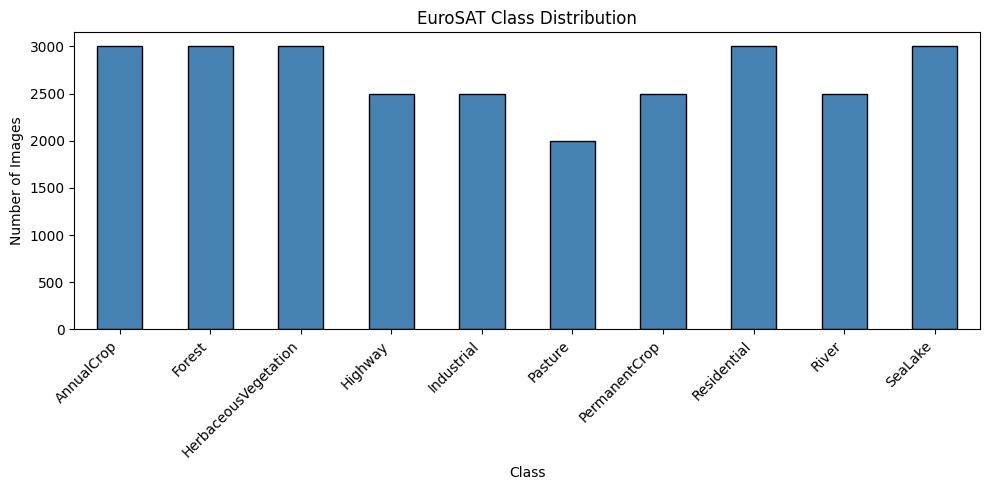

In [4]:
# ----------------------------------------------------------------------
# 3. CLASS DISTRIBUTION
# ----------------------------------------------------------------------
class_counts = df["label"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("EuroSAT Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

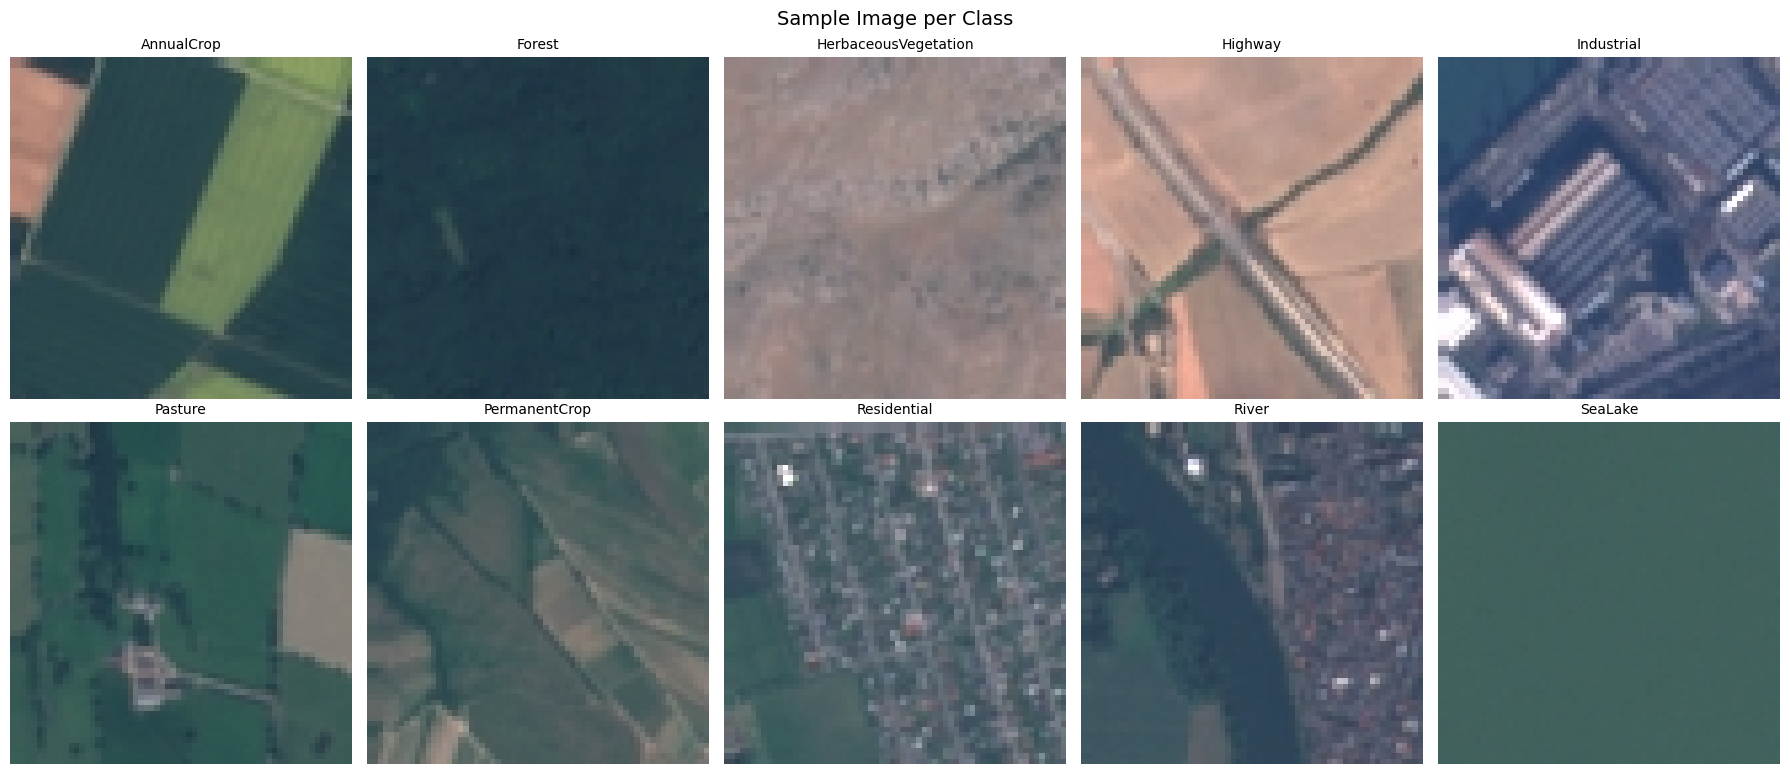

In [5]:
# ----------------------------------------------------------------------
# 4. SAMPLE IMAGES PER CLASS (VISUAL CHECK)
# ----------------------------------------------------------------------
n_classes = len(class_names)
fig, axes = plt.subplots(nrows=(n_classes + 4) // 5, ncols=5, figsize=(18, 4 * ((n_classes + 4) // 5)))
axes = axes.flatten()

for ax, cls in zip(axes, class_names):
    sample_path = df[df["label"] == cls]["filepath"].sample(1, random_state=SEED).values[0]
    img = Image.open(sample_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

for ax in axes[len(class_names):]:
    ax.axis("off")

plt.suptitle("Sample Image per Class", fontsize=14)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [6]:
# ----------------------------------------------------------------------
# 5. IMAGE PROPERTIES: SIZE, MODE, CHANNELS
# ----------------------------------------------------------------------
def image_properties(path):
    with Image.open(path) as img:
        return img.size, img.mode  # (width, height), mode


sample_n = min(500, len(df))
sample_df = df.sample(sample_n, random_state=SEED)

sizes, modes = [], []
for p in sample_df["filepath"]:
    size, mode = image_properties(p)
    sizes.append(size)
    modes.append(mode)

sizes_counter = Counter(sizes)
modes_counter = Counter(modes)

print("\nImage size distribution (sampled):", sizes_counter)
print("Image mode/channel distribution (sampled):", modes_counter)



Image size distribution (sampled): Counter({(64, 64): 500})
Image mode/channel distribution (sampled): Counter({'RGB': 500})


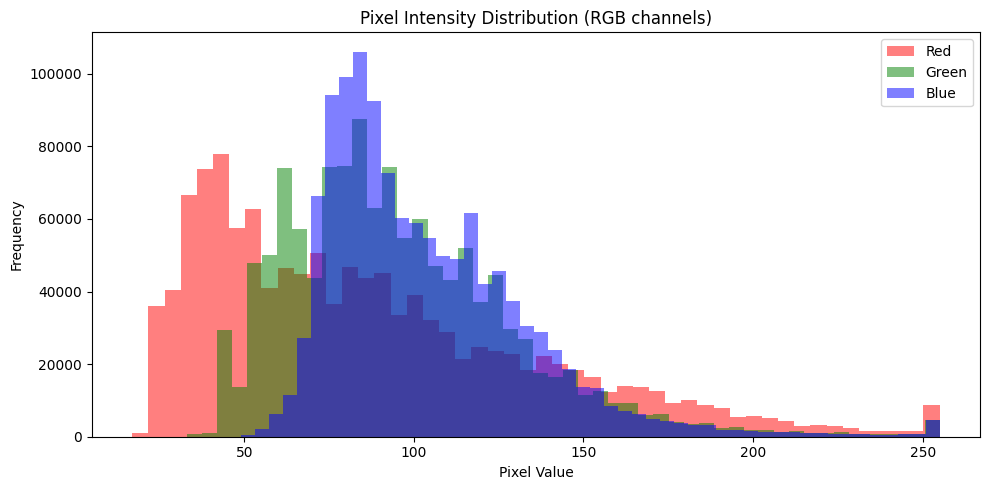


Channel means (0-255): [ 87.26110758  96.22694173 103.93472819]
Channel stds (0-255): [49.70585835 34.53725185 29.86260188]


In [7]:
# ----------------------------------------------------------------------
# 6. PIXEL INTENSITY DISTRIBUTION (OVERALL + PER CHANNEL)
# ----------------------------------------------------------------------
def load_as_array(path, size=(64, 64)):
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size)
        return np.array(img)


pixel_sample_n = min(300, len(df))
pixel_sample = df.sample(pixel_sample_n, random_state=SEED)

all_pixels = np.stack([load_as_array(p) for p in pixel_sample["filepath"]])  # (N, H, W, 3)
r_vals = all_pixels[..., 0].ravel()
g_vals = all_pixels[..., 1].ravel()
b_vals = all_pixels[..., 2].ravel()

plt.figure(figsize=(10, 5))
plt.hist(r_vals, bins=50, alpha=0.5, color="red", label="Red")
plt.hist(g_vals, bins=50, alpha=0.5, color="green", label="Green")
plt.hist(b_vals, bins=50, alpha=0.5, color="blue", label="Blue")
plt.title("Pixel Intensity Distribution (RGB channels)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("pixel_intensity_hist.png", dpi=150)
plt.show()

print("\nChannel means (0-255):", all_pixels.reshape(-1, 3).mean(axis=0))
print("Channel stds (0-255):", all_pixels.reshape(-1, 3).std(axis=0))


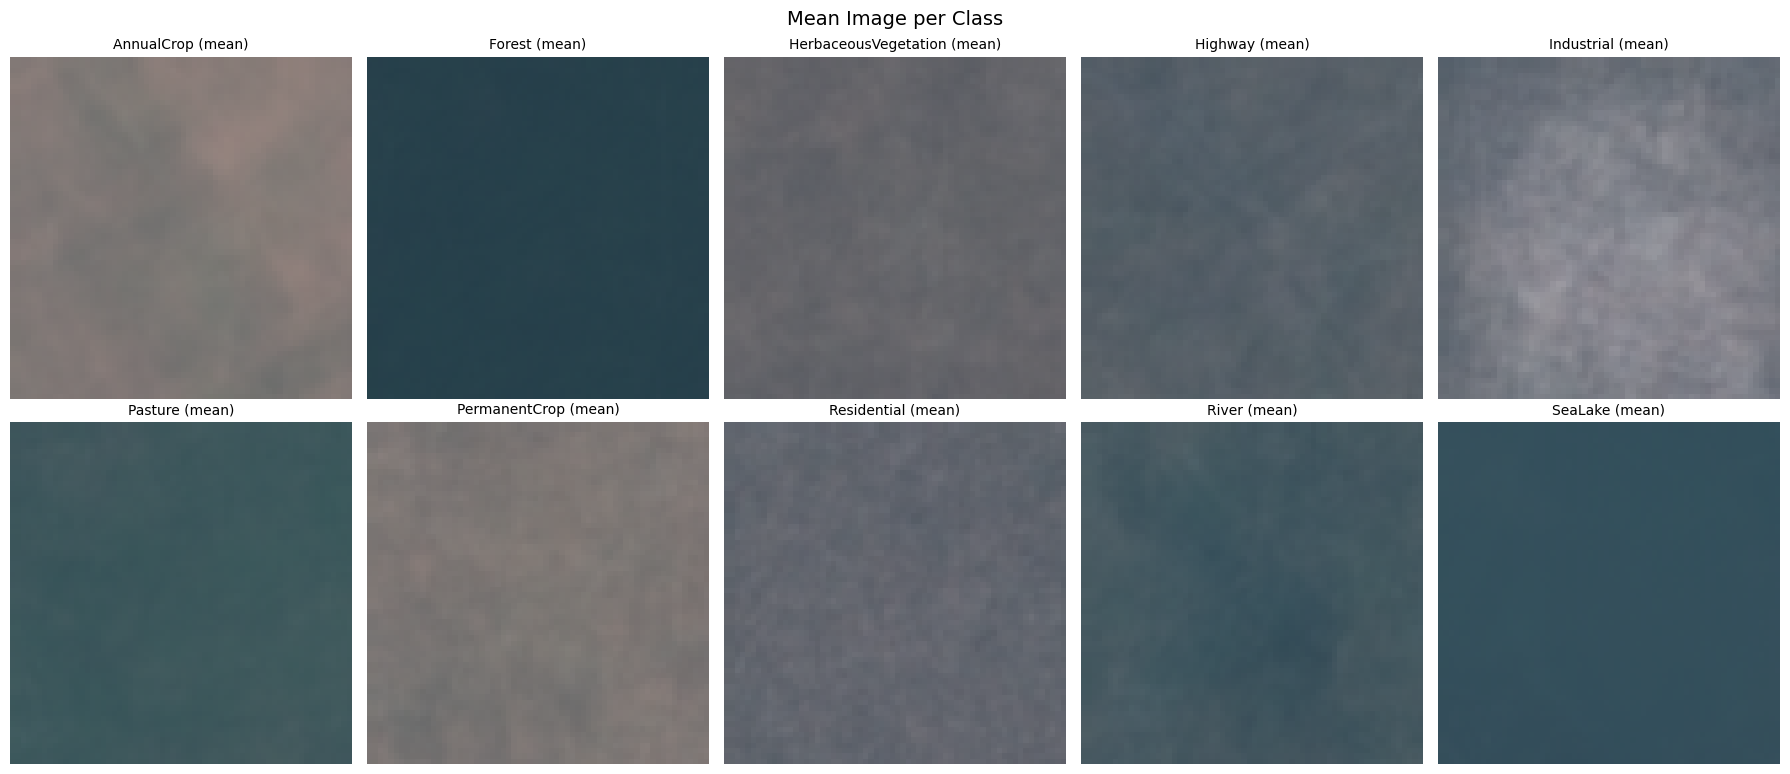

In [8]:
# ----------------------------------------------------------------------
# 7. MEAN IMAGE PER CLASS (helps spot visual class differences)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(nrows=(n_classes + 4) // 5, ncols=5, figsize=(18, 4 * ((n_classes + 4) // 5)))
axes = axes.flatten()

for ax, cls in zip(axes, class_names):
    cls_paths = df[df["label"] == cls]["filepath"].sample(min(50, len(df[df["label"] == cls])), random_state=SEED)
    imgs = np.stack([load_as_array(p) for p in cls_paths])
    mean_img = imgs.mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(f"{cls} (mean)", fontsize=10)
    ax.axis("off")

for ax in axes[len(class_names):]:
    ax.axis("off")

plt.suptitle("Mean Image per Class", fontsize=14)
plt.tight_layout()
plt.savefig("mean_images_per_class.png", dpi=150)
plt.show()

In [9]:
# ----------------------------------------------------------------------
# 8. SUMMARY
# ----------------------------------------------------------------------
print("\n=== EDA SUMMARY ===")
print(f"Total images: {len(df)}")
print(f"Number of classes: {len(class_names)}")
print(f"Class balance (min/max count): {class_counts.min()} / {class_counts.max()}")
print(f"Most common image size (sampled): {sizes_counter.most_common(1)}")
print(f"Most common image mode (sampled): {modes_counter.most_common(1)}")



=== EDA SUMMARY ===
Total images: 27000
Number of classes: 10
Class balance (min/max count): 2000 / 3000
Most common image size (sampled): [((64, 64), 500)]
Most common image mode (sampled): [('RGB', 500)]


In [10]:
# ----------------------------------------------------------------------
# 9. BUILD FILE INDEX
# ----------------------------------------------------------------------
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes:", classes)

records = []
for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".tif", ".tiff")):
            records.append({"filepath": os.path.join(cls_dir, f), "label": cls})

df = pd.DataFrame(records)
print(f"Total images: {len(df)}")


Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000


In [11]:
# ----------------------------------------------------------------------
# 10 MISSING / CORRUPT FILE CHECK  (done early so later steps use only good files)
# ----------------------------------------------------------------------
check_df = df if CORRUPT_CHECK_ALL else df.sample(min(1000, len(df)), random_state=SEED)

corrupt_files = []
for path in check_df["filepath"]:
    try:
        with rasterio.open(path) as src:
            arr = src.read()
            if arr.size == 0 or np.isnan(arr).all():
                corrupt_files.append(path)
    except Exception as e:
        corrupt_files.append(path)

print(f"\nChecked {len(check_df)} files -> {len(corrupt_files)} corrupt/unreadable")
if corrupt_files:
    print("Examples of corrupt files:", corrupt_files[:5])

# drop corrupt files from the working dataframe
df = df[~df["filepath"].isin(corrupt_files)].reset_index(drop=True)


Checked 27000 files -> 0 corrupt/unreadable


In [12]:
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
records = []
for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".tif", ".tiff")):
            records.append({"filepath": os.path.join(cls_dir, f), "label": cls})
df = pd.DataFrame(records)
print("df rows:", len(df))  # should be 27000



df rows: 27000


In [13]:
# ----------------------------------------------------------------------
# 11. IMAGE SIZE & DTYPE CONSISTENCY CHECK
# ----------------------------------------------------------------------
size_dtype_records = []
sample_for_meta = df.sample(min(500, len(df)), random_state=SEED)

for path in sample_for_meta["filepath"]:
    with rasterio.open(path) as src:
        size_dtype_records.append({
            "width": src.width,
            "height": src.height,
            "bands": src.count,
            "dtype": src.dtypes[0],
        })

meta_df = pd.DataFrame(size_dtype_records)
print("\nImage size distribution:\n", meta_df.groupby(["width", "height"]).size())
print("\nBand count distribution:\n", meta_df["bands"].value_counts())
print("\nDtype distribution:\n", meta_df["dtype"].value_counts())

if meta_df[["width", "height", "bands", "dtype"]].nunique().eq(1).all():
    print("\n✅ All sampled images have consistent size/bands/dtype.")
else:
    print("\n⚠️ Inconsistencies found in size/bands/dtype - inspect meta_df.")


Image size distribution:
 width  height
64     64        500
dtype: int64

Band count distribution:
 bands
13    500
Name: count, dtype: int64

Dtype distribution:
 dtype
uint16    500
Name: count, dtype: int64

✅ All sampled images have consistent size/bands/dtype.


In [14]:
# ----------------------------------------------------------------------
# HELPER: load a full 13-band array, normalized 0-1 for display purposes
# ----------------------------------------------------------------------
def load_bands(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)  # (bands, H, W)
    return arr


def to_rgb_display(arr, r=BAND_RED, g=BAND_GREEN, b=BAND_BLUE):
    rgb = np.stack([arr[r], arr[g], arr[b]], axis=-1)
    # percentile stretch for visibility
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)
    return rgb

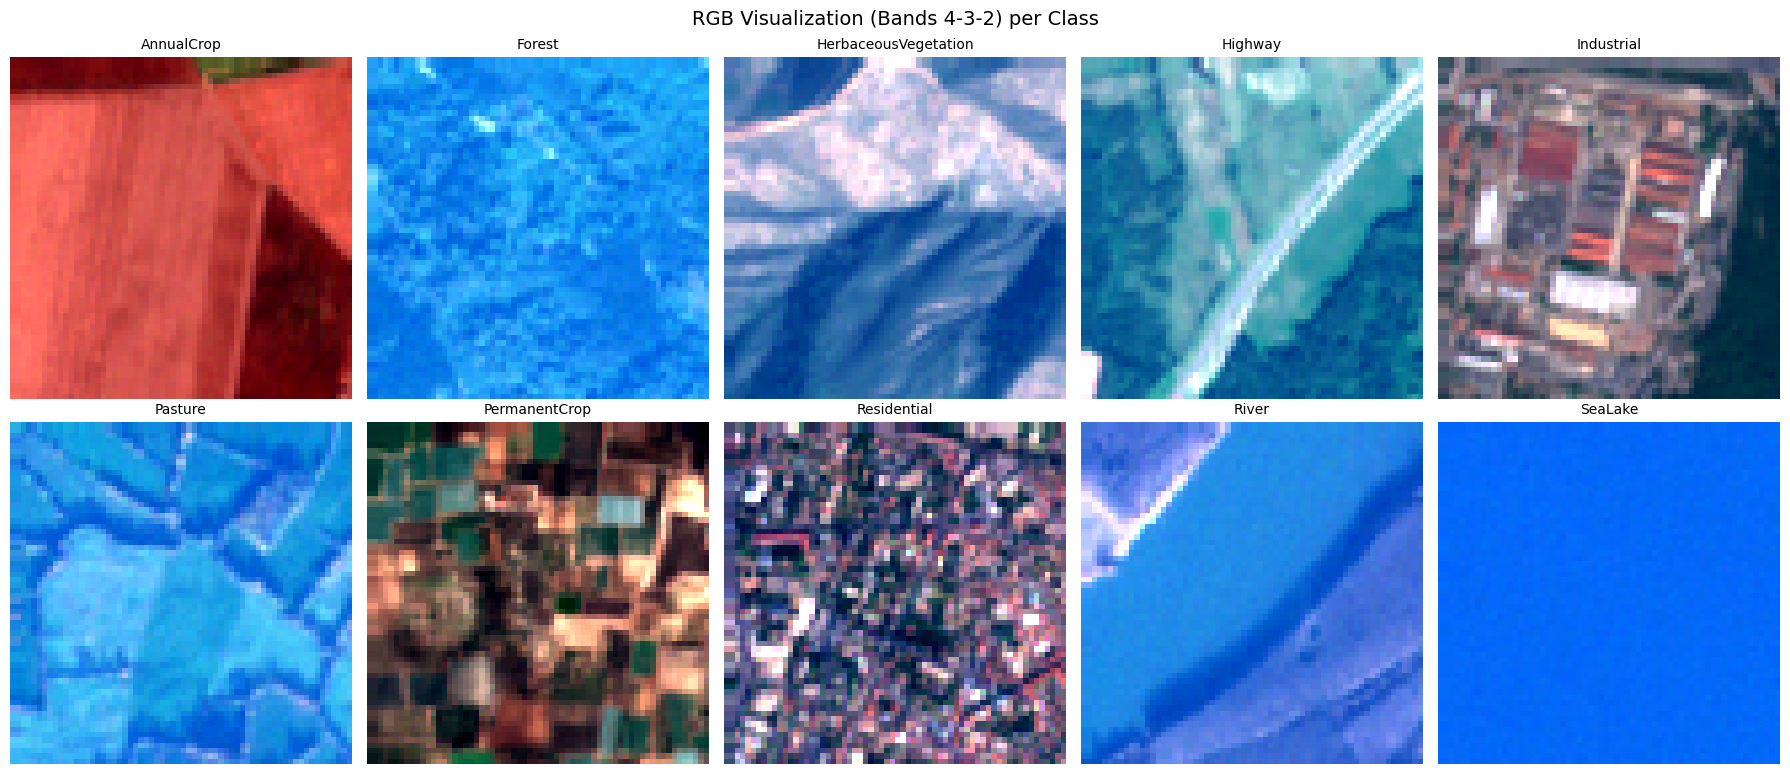

In [15]:
# ----------------------------------------------------------------------
# 12. RGB VISUALIZATION (sample per class)
# ----------------------------------------------------------------------
n_classes = len(classes)
fig, axes = plt.subplots(nrows=(n_classes + 4) // 5, ncols=5, figsize=(18, 4 * ((n_classes + 4) // 5)))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sample_path = df[df["label"] == cls]["filepath"].sample(1, random_state=SEED).values[0]
    arr = load_bands(sample_path)
    rgb = to_rgb_display(arr)
    ax.imshow(rgb)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("RGB Visualization (Bands 4-3-2) per Class", fontsize=14)
plt.tight_layout()
plt.savefig("rgb_per_class.png", dpi=150)
plt.show()


Overall per-band pixel statistics (sampled):
     band         mean          std
0    B01  1359.130371   224.372269
1    B02  1122.516479   263.238556
2    B03  1045.035400   325.011444
3    B04   947.352112   489.209473
4    B05  1190.086182   504.044830
5    B06  1978.353394   780.391357
6    B07  2342.695557   972.618469
7    B08  2264.642334   962.062256
8   B08A   696.072632   379.411499
9    B09    11.865476     4.183813
10   B10  1800.789185   915.833679
11   B11  1106.054443   673.938354
12   B12  2562.212158  1111.205566


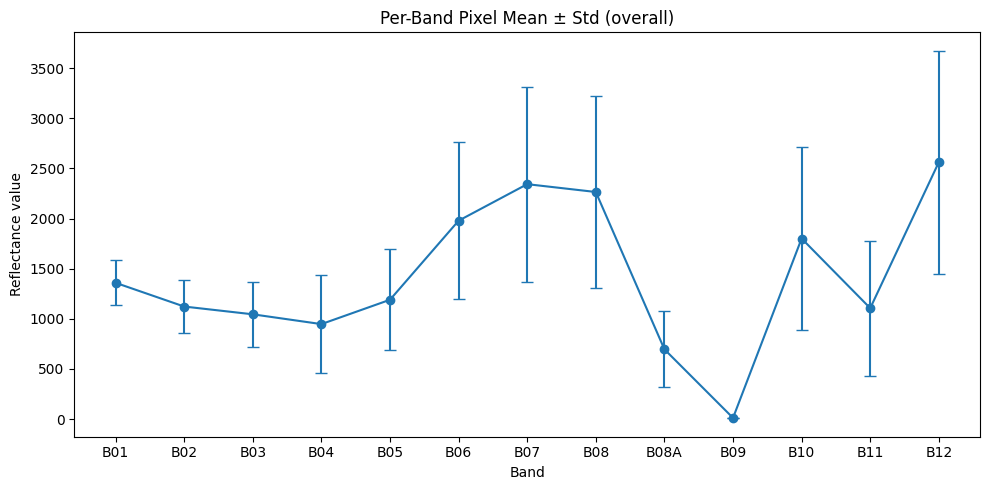

In [16]:
# ----------------------------------------------------------------------
# 13. PIXEL VALUE STATISTICS (per-band mean/std) + 5. CLASS-WISE SPECTRAL SIGNATURE
# ----------------------------------------------------------------------
sample_df = df.sample(min(STATS_SAMPLE_N, len(df)), random_state=SEED)

band_stack = []
labels_for_stack = []
for _, row in sample_df.iterrows():
    arr = load_bands(row["filepath"])  # (13, H, W)
    band_stack.append(arr.reshape(arr.shape[0], -1).mean(axis=1))  # per-image mean per band
    labels_for_stack.append(row["label"])

band_means_per_image = np.array(band_stack)  # (N, 13)
labels_for_stack = np.array(labels_for_stack)

overall_mean = band_means_per_image.mean(axis=0)
overall_std = band_means_per_image.std(axis=0)

stats_df = pd.DataFrame({"band": BAND_NAMES, "mean": overall_mean, "std": overall_std})
print("\nOverall per-band pixel statistics (sampled):\n", stats_df)

plt.figure(figsize=(10, 5))
plt.errorbar(BAND_NAMES, overall_mean, yerr=overall_std, fmt="-o", capsize=4)
plt.title("Per-Band Pixel Mean ± Std (overall)")
plt.xlabel("Band")
plt.ylabel("Reflectance value")
plt.tight_layout()
plt.savefig("band_mean_std.png", dpi=150)
plt.show()

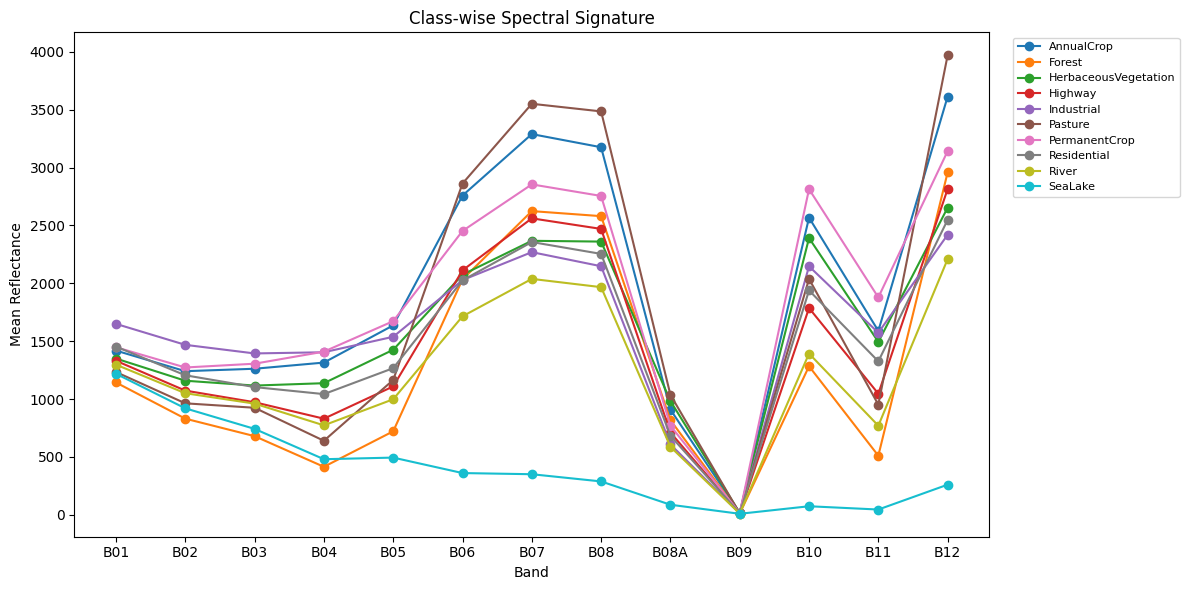

In [17]:
# Class-wise spectral signature
plt.figure(figsize=(12, 6))
for cls in classes:
    cls_mask = labels_for_stack == cls
    if cls_mask.sum() == 0:
        continue
    cls_signature = band_means_per_image[cls_mask].mean(axis=0)
    plt.plot(BAND_NAMES, cls_signature, marker="o", label=cls)

plt.title("Class-wise Spectral Signature")
plt.xlabel("Band")
plt.ylabel("Mean Reflectance")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("spectral_signature_by_class.png", dpi=150)
plt.show()

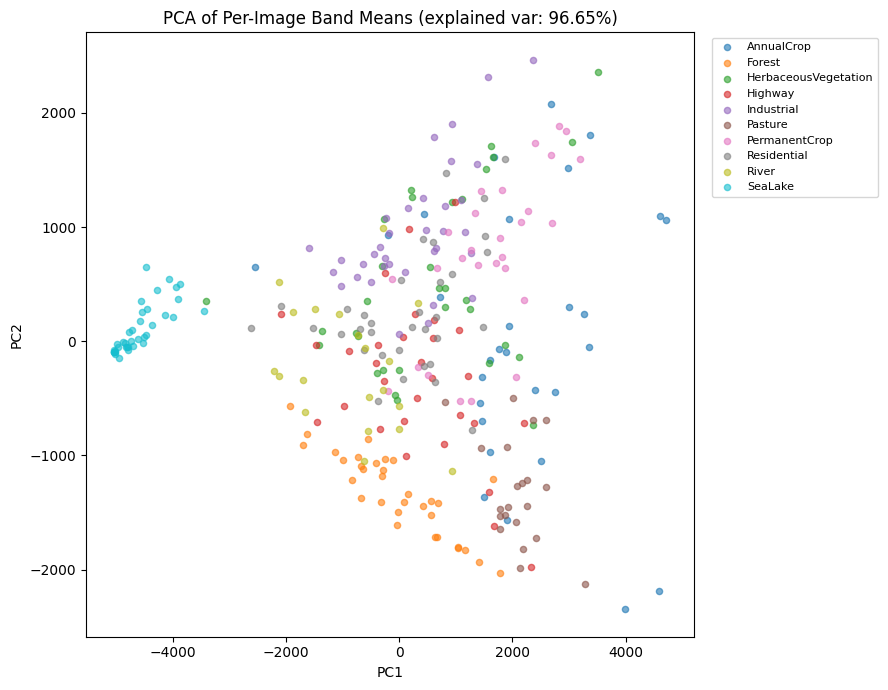

In [18]:
# ----------------------------------------------------------------------
# 14. PCA CLASS SEPARABILITY
# ----------------------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
pca_result = pca.fit_transform(band_means_per_image)

plt.figure(figsize=(9, 7))
for cls in classes:
    mask = labels_for_stack == cls
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], label=cls, alpha=0.6, s=20)

plt.title(f"PCA of Per-Image Band Means (explained var: {pca.explained_variance_ratio_.sum():.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("pca_class_separability.png", dpi=150)
plt.show()

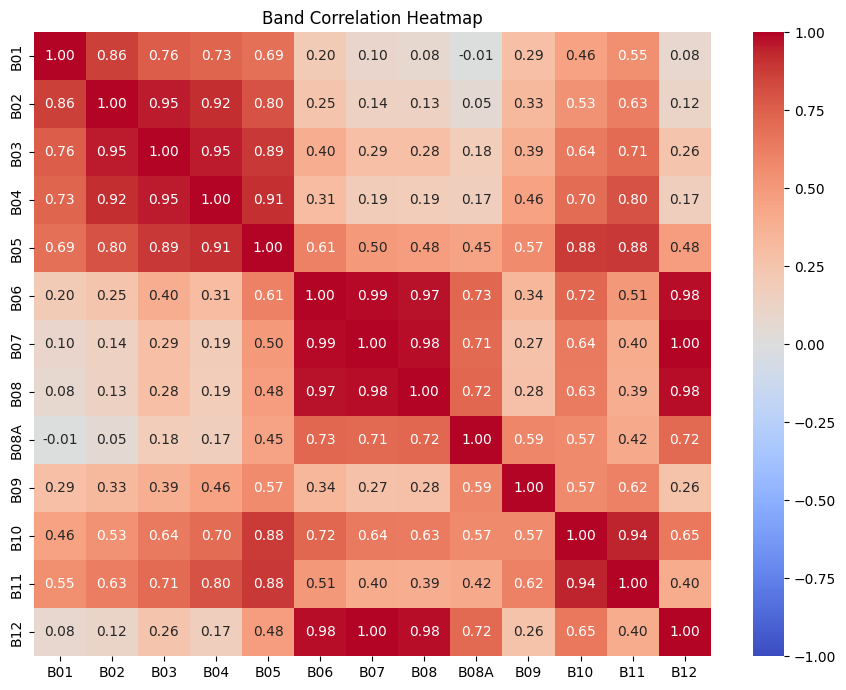

In [19]:
# ----------------------------------------------------------------------
# 15. BAND CORRELATION HEATMAP
# ----------------------------------------------------------------------
# use all pixels (not just per-image means) from a smaller sub-sample for a truer picture
import seaborn as sns
corr_sample = df.sample(min(80, len(df)), random_state=SEED)
all_pixel_rows = []
for path in corr_sample["filepath"]:
    arr = load_bands(path)  # (13, H, W)
    flat = arr.reshape(arr.shape[0], -1).T  # (H*W, 13)
    all_pixel_rows.append(flat)

pixel_matrix = np.concatenate(all_pixel_rows, axis=0)  # (N_pixels, 13)
corr_matrix = np.corrcoef(pixel_matrix, rowvar=False)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, xticklabels=BAND_NAMES, yticklabels=BAND_NAMES,
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Band Correlation Heatmap")
plt.tight_layout()
plt.savefig("band_correlation_heatmap.png", dpi=150)
plt.show()

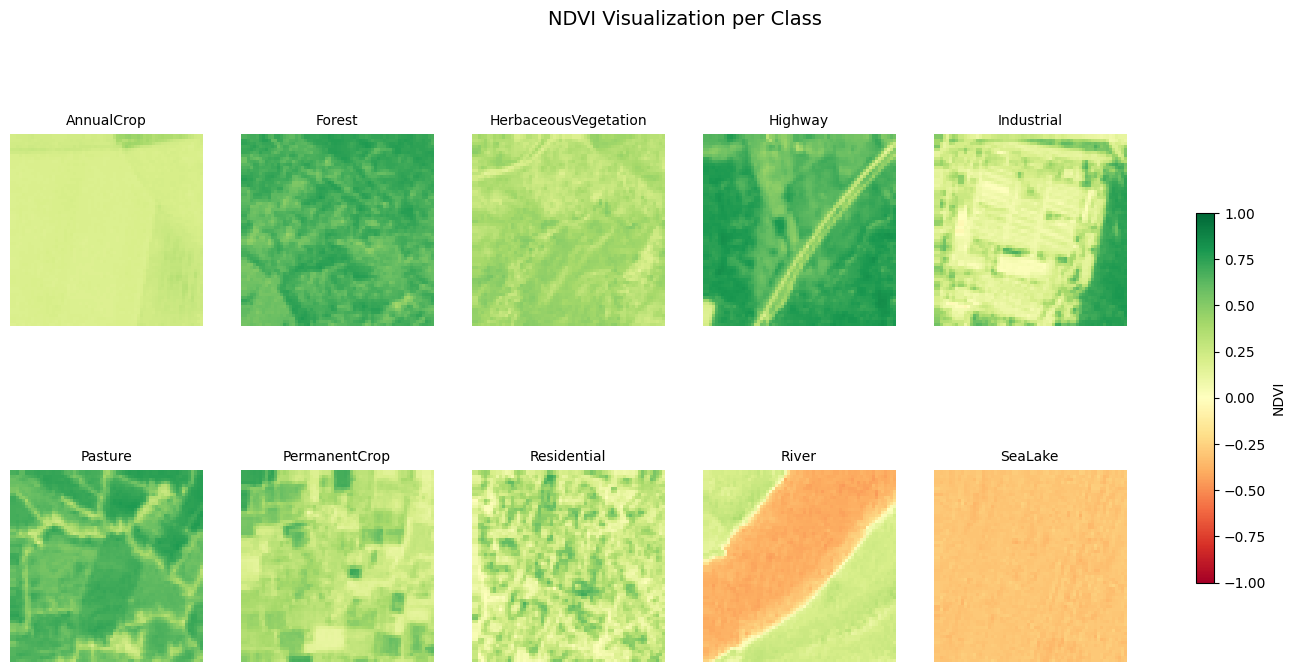

In [20]:
# ----------------------------------------------------------------------
# 16. NDVI VISUALIZATION
# ----------------------------------------------------------------------
def compute_ndvi(arr, red=BAND_RED, nir=BAND_NIR):
    red_band = arr[red].astype(np.float32)
    nir_band = arr[nir].astype(np.float32)
    ndvi = (nir_band - red_band) / (nir_band + red_band + 1e-6)
    return ndvi


fig, axes = plt.subplots(nrows=(n_classes + 4) // 5, ncols=5, figsize=(18, 4 * ((n_classes + 4) // 5)))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sample_path = df[df["label"] == cls]["filepath"].sample(1, random_state=SEED).values[0]
    arr = load_bands(sample_path)
    ndvi = compute_ndvi(arr)
    im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.6, label="NDVI")
plt.suptitle("NDVI Visualization per Class", fontsize=14)
plt.savefig("ndvi_per_class.png", dpi=150)
plt.show()



Train/Val/Test split summary (70/15/15, stratified):
                       train  val  test  total
label                                        
AnnualCrop             2100  450   450   3000
Forest                 2100  450   450   3000
HerbaceousVegetation   2100  450   450   3000
Highway                1750  375   375   2500
Industrial             1750  375   375   2500
Pasture                1400  300   300   2000
PermanentCrop          1750  375   375   2500
Residential            2100  450   450   3000
River                  1750  375   375   2500
SeaLake                2100  450   450   3000


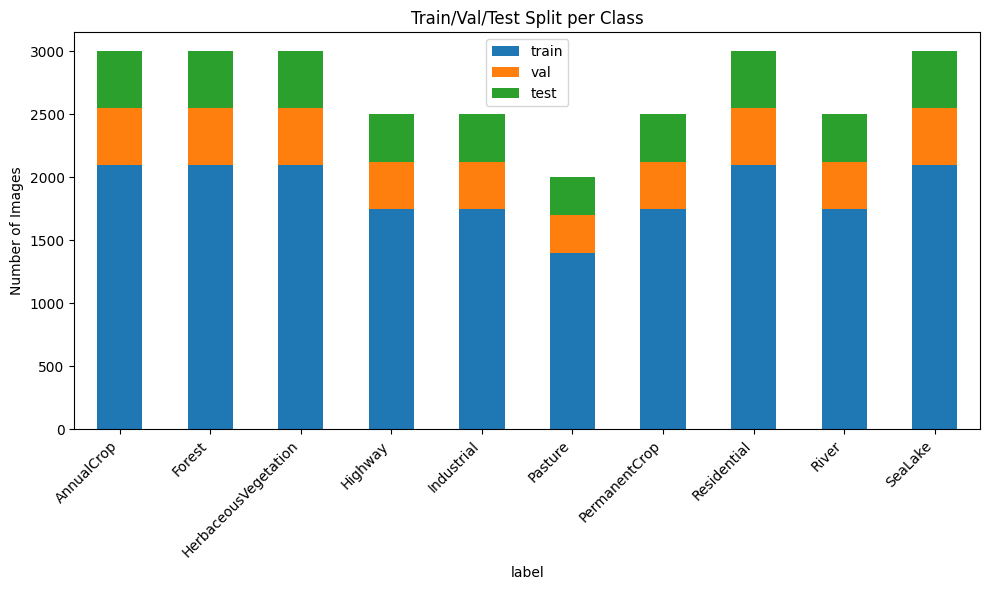


Final counts -> train: 18900, val: 4050, test: 4050

=== EDA COMPLETE ===


In [21]:
# ----------------------------------------------------------------------
# 17. TRAIN / VAL / TEST SPLIT SUMMARY
# ----------------------------------------------------------------------
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int)

split_summary["total"] = split_summary.sum(axis=1)
print("\nTrain/Val/Test split summary (70/15/15, stratified):\n", split_summary)

fig, ax = plt.subplots(figsize=(10, 6))
split_summary[["train", "val", "test"]].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Train/Val/Test Split per Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("split_summary.png", dpi=150)
plt.show()

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print(f"\nFinal counts -> train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print("\n=== EDA COMPLETE ===")
